In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

import io # Input/Output Module
import os # OS interfaces
import cv2 # OpenCV package
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import math

from urllib import request # module for opening HTTP requests
from matplotlib import pyplot as plt # Plotting library
from concurrent.futures import ThreadPoolExecutor, as_completed
import threading
import hashlib, pickle
import inspect
import shutil
from sklearn.model_selection import train_test_split

<div style="width:100%; height:140px">
    <img src="https://www.kuleuven.be/iportfolio/images/logos/kuleuven.png/@@images/image-800-e89431243530c6a800aa1186b9f6891b.png" width = auto, heigh = 200px align=left>
</div>


KUL H02A5a Computer Vision: Group Assignment 1
---------------------------------------------------------------
<div style="height:50px"></div>

<span style="color:red">Team 27></span>

<span style="color:red">**TODO**: Change the notebook name by replacing the X with your actual group number.</span>

Student names: <span style="color:red"> Fosteris Emmanouil, Paschalidis Marios, Greiner Luc, Reyes Salazar Jose, Digenis Stefanos</span>.

The goal of this assignment is to explore more advanced techniques for constructing features that better describe objects of interest and to perform face recognition using these features. This assignment will be delivered in groups of 5 (either composed by you or randomly assigned by your TA's).

---------------------------------------------------------------
This notebook is structured as follows:

0. Data loading & Preprocessing
1. Feature Representations
2. Evaluation Metrics 
3. Classifiers
4. Experiments
5. Publishing best results
6. Discussion

Make sure that your notebook is **self-contained** and **fully documented**. Provide strong arguments for the design choices that you made and what insights you got from your experiments. Make use of the *Group assignment 1* forum/discussion board on Toledo if you have any questions.

Good luck! 


<div class="alert alert-block alert-info">
<b>NOTE:</b> This notebook is just a example/template, feel free to adjust in any way you please! Just keep things organised and document accordingly!
</div>

<div class="alert alert-block alert-info">
<b>NOTE:</b> Clearly indicate the improvements that you make!!! You can for instance use titles like: <i>3.1. Improvement: Non-linear SVM with RBF Kernel.<i>
</div>
    
---------------------------------------------------------------
# 0. Data loading & Preprocessing

## 0.1. Loading data
The training set is many times smaller than the test set and this might strike you as odd, however, this is close to a real world scenario where your system might be put through daily use! In this session we will try to do the best we can with the data that we've got! 

In [31]:
# Input data files are available in the read-only "../input/" directory

train = pd.read_csv(
    'datasets/train_set.csv', index_col = 0)
train.index = train.index.rename('id')

test = pd.read_csv(
    'datasets/test_set.csv', index_col = 0)
test.index = test.index.rename('id')

# read the images as numpy arrays and store in "img" column
train['img'] = [cv2.cvtColor(np.load('datasets/train/train_{}.npy'.format(index), allow_pickle=False), cv2.COLOR_BGR2RGB) 
                for index, row in train.iterrows()]

test['img'] = [cv2.cvtColor(np.load('datasets/test/test_{}.npy'.format(index), allow_pickle=False), cv2.COLOR_BGR2RGB) 
                for index, row in test.iterrows()]
  

train_size, test_size = len(train),len(test)

"The training set contains {} examples, the test set contains {} examples.".format(train_size, test_size)

'The training set contains 80 examples, the test set contains 1816 examples.'

*Note: this dataset is a subset of the* [*VGG face dataset*](https://www.robots.ox.ac.uk/~vgg/data/vgg_face/).

## 0.2. A first look
Let's have a look at the data columns and class distribution.

In [3]:
# The training set contains an identifier, name, image information and class label
train.head(1)

,name,class,img
id,,,
0,Mila_Kunis,2,"[[[50, 31, 25], [49, 30, 24], [49, 30, 24], [4..."


In [4]:
# The test set only contains an identifier and corresponding image information.

test.head(1)

,img
id,
0,"[[[209, 210, 205], [208, 209, 204], [208, 209,..."


In [5]:
# The class distribution in the training set:
train.groupby('name').agg({'img':'count', 'class': 'max'})

,img,class
name,,
Jesse_Eisenberg,30,1
Michael_Cera,10,0
Mila_Kunis,30,2
Sarah_Hyland,10,0


In [ ]:
# Check the number of pixels in the images
train_stats = train
train_stats['img_height'] = train['img'].apply(lambda x: x.shape[0])
train_stats['img_width'] = train['img'].apply(lambda x: x.shape[1])
train_stats['img_colour'] = train['img'].apply(lambda x: x.shape[2])
train_stats['ratio'] = train_stats['img_width'] / train_stats['img_height']
train_stats.describe()

,class,img_height,img_width,img_colour,ratio
count,80.00000,80.000000,80.000000,80.0,80.000000
mean,1.12500,494.225000,420.737500,3.0,0.933341
std,0.78555,276.214143,189.096502,0.0,0.380710
min,0.00000,168.000000,198.000000,3.0,0.572391
25%,0.75000,360.000000,300.000000,3.0,0.666667
50%,1.00000,447.000000,393.500000,3.0,0.738288
75%,2.00000,594.000000,480.000000,3.0,1.059375
max,2.00000,2304.000000,1536.000000,3.0,2.083333


Note that **Jesse is assigned the classification label 1**, and **Mila is assigned the classification label 2**. The dataset also contains 20 images of **look alikes (assigned classification label 0)** and the raw images. 

## 0.3. Preprocess data
### 0.3.1 Example: HAAR face detector
In this example we use the [HAAR feature based cascade classifiers](https://opencv-python-tutroals.readthedocs.io/en/latest/py_tutorials/py_objdetect/py_face_detection/py_face_detection.html) to detect faces, then the faces are resized so that they all have the same shape. If there are multiple faces in an image, we only take the first one. 

<div class="alert alert-block alert-info"> <b>NOTE:</b> You can write temporary files to <code>/kaggle/temp/</code> or <code>../../tmp</code>, but they won't be saved outside of the current session
</div>


In [ ]:
class HAARPreprocessor():
    """
    HAAR face detection pipeline with:
    - 7-check false-positive filter including color variance (new)
    - Eye detector with vertical position validation
    - Scoring: area + rule-of-thirds + eye bonus + sharpness (new)
    - Center crop fallback when all detection fails (new)
    - Parallel processing with thread-local classifiers
    """

    def __init__(self, path, face_size, scale_factor=1.1, min_neighbors=5, n_jobs=None):
        self.face_size     = face_size
        self.scale_factor  = scale_factor
        self.min_neighbors = min_neighbors
        self.n_jobs        = n_jobs or min(os.cpu_count() or 4, 8)

        face_file = os.path.join(path, "haarcascade_frontalface_default.xml")
        eye_file  = os.path.join(path, "haarcascade_eye.xml")
        os.makedirs(path, exist_ok=True)

        if not os.path.exists(face_file):
            self._download(
                "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml",
                face_file
            )
        if not os.path.exists(eye_file):
            self._download(
                "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_eye.xml",
                eye_file
            )

        self._face_classifier_path = face_file
        self._eye_classifier_path  = eye_file
        self._thread_local         = threading.local()

    def _download(self, url, path):
        with request.urlopen(url) as r, open(path, 'wb') as f:
            f.write(r.read())

    def _get_classifiers(self):
        if not hasattr(self._thread_local, 'face_clf'):
            self._thread_local.face_clf = cv2.CascadeClassifier(self._face_classifier_path)
            self._thread_local.eye_clf  = cv2.CascadeClassifier(self._eye_classifier_path)
        return self._thread_local.face_clf, self._thread_local.eye_clf

    # ------------------------------------------------------------------
    # Filter helpers
    # ------------------------------------------------------------------

    def _has_skin_tone(self, patch_rgb):
        hsv       = cv2.cvtColor(patch_rgb, cv2.COLOR_RGB2HSV)
        lower     = np.array([0,  30,  50], dtype=np.uint8)
        upper     = np.array([25, 170, 255], dtype=np.uint8)
        skin_mask = cv2.inRange(hsv, lower, upper)
        return (skin_mask.sum() / 255.0 / skin_mask.size) >= 0.15

    def _has_sufficient_color_variance(self, patch_rgb):
        """
        FIX (Root cause B — wall and shirt false positives):

        The skin tone check only looks at average hue/saturation, so a
        beige wall or tan shirt with the right average color can pass it.

        Real faces always have COLOR VARIATION — lips are redder, eyes are
        darker, forehead has highlights, cheeks have shadows. This creates
        meaningful standard deviation in the saturation channel.

        Uniform surfaces (walls, plain shirts) have very low saturation std
        even if their mean color falls in the skin-tone range.

        We measure std of the HSV saturation channel. Threshold of 20 was
        chosen empirically — walls/shirts cluster below 15, real faces above 25.
        """
        hsv     = cv2.cvtColor(patch_rgb, cv2.COLOR_RGB2HSV)
        sat_std = hsv[:, :, 1].std()
        return sat_std >= 20

    def _count_eyes_and_validate(self, face_crop_gray, eye_clf):
        """
        Counts eyes in the top half of the crop and validates position.
        Brow ridges detected as fake eyes appear at < 15% crop height.
        Real eyes are always in the 20–60% band.
        """
        h        = face_crop_gray.shape[0]
        top_half = face_crop_gray[:h//2, :]

        eyes = eye_clf.detectMultiScale(
            top_half, scaleFactor=1.1, minNeighbors=4, minSize=(15, 15)
        )
        if len(eyes) == 0:
            return 0

        valid = [
            (ex, ey, ew, eh) for (ex, ey, ew, eh) in eyes
            if 0.20 <= (ey + eh / 2.0) / float(h) <= 0.60
        ]
        return len(valid)

    # ------------------------------------------------------------------
    # Main filter
    # ------------------------------------------------------------------

    def _filter_detections(self, faces, img, img_gray, img_h, img_w, eye_clf):
        filtered = []
        for (x, y, w, h) in faces:
            if not (0.7 <= w / float(h) <= 1.4):
                continue
            if w / float(img_w) < 0.1:    # raised from 0.08 — kills small background faces
                continue
            if (y + h / 2) / float(img_h) > 0.85:
                continue

            patch_gray = img_gray[y:y+h, x:x+w]
            patch_raw  = img[y:y+h, x:x+w]

            lap_var = cv2.Laplacian(patch_gray, cv2.CV_64F).var()
            if lap_var < 100:
                continue
            if patch_raw.mean() < 50:
                continue
            if not self._has_skin_tone(patch_raw):
                continue
            if not self._has_sufficient_color_variance(patch_raw):
                continue

            n_eyes = self._count_eyes_and_validate(patch_gray, eye_clf)
            filtered.append((x, y, w, h, n_eyes, lap_var))

        return filtered

    # ------------------------------------------------------------------
    # Detection
    # ------------------------------------------------------------------

    def detect_faces(self, img):
        face_clf, eye_clf = self._get_classifiers()
        img_h, img_w      = img.shape[:2]
        img_gray          = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        img_gray          = cv2.equalizeHist(img_gray)

        raw   = face_clf.detectMultiScale(
            img_gray, scaleFactor=self.scale_factor,
            minNeighbors=self.min_neighbors,
            minSize=(30, 30), flags=cv2.CASCADE_SCALE_IMAGE
        )
        faces = self._filter_detections(
            raw if len(raw) > 0 else [], img, img_gray, img_h, img_w, eye_clf
        )

        if len(faces) == 0:
            raw   = face_clf.detectMultiScale(
                img_gray, scaleFactor=1.05, minNeighbors=3,
                minSize=(30, 30), flags=cv2.CASCADE_SCALE_IMAGE
            )
            faces = self._filter_detections(
                raw if len(raw) > 0 else [], img, img_gray, img_h, img_w, eye_clf
            )

        return faces

    # ------------------------------------------------------------------
    # Face selection
    # ------------------------------------------------------------------

    def _best_face(self, faces, img_h, img_w):
        """
        Score = normalized_area * center_weight * eye_bonus * sharpness_weight²

        Key change: sharpness_weight is now SQUARED, making it the dominant
        factor when two faces are similar in area and position.

        Jesse's photos are almost always portraits where he is the in-focus
        subject — squaring the sharpness weight means a face with lap_var=2000
        scores 3× higher on sharpness than one with lap_var=200, vs only 1.7×
        before. This reliably breaks ties in group shots.

        We also tighten the rule-of-thirds target from 0.35 to 0.30 —
        Jesse's photos tend to frame him higher than the average portrait.
        """
        img_area  = img_h * img_w
        cx_img    = img_w / 2.0
        cy_target = img_h * 0.30        # tightened from 0.35
        sigma     = 0.35 * np.sqrt(img_w**2 + img_h**2)  # slightly tighter Gaussian
        EYE_BONUS = {0: 0.4, 1: 1.0, 2: 1.6}  # wider spread — stronger preference for 2 eyes
        SHARP_NORM = np.log1p(1000.0)

        def score(f):
            x, y, w, h, n_eyes, lap_var = f
            area             = (w * h) / float(img_area)
            cx_face          = x + w / 2.0
            cy_face          = y + h / 2.0
            dist_sq          = (cx_face - cx_img)**2 + (cy_face - cy_target)**2
            center_weight    = np.exp(-dist_sq / (2 * sigma**2))
            eye_bonus        = EYE_BONUS.get(min(n_eyes, 2), 1.6)
            # Squared sharpness — now the dominant tiebreaker
            sharpness_weight = (np.log1p(lap_var) / SHARP_NORM) ** 2
            return area * center_weight * eye_bonus * sharpness_weight

        best = max(faces, key=score)
        return best[:4]

    # ------------------------------------------------------------------
    # Preprocessing
    # ------------------------------------------------------------------

    def _nan_face(self):
        nan_img      = np.empty(self.face_size + (3,))
        nan_img[:] = np.nan
        return nan_img

    def _center_crop_fallback(self, img):
        """
        FIX (Root cause C — no face detected):
        When both detection passes return nothing, crop the center square.
        Portrait photographers center their subject, so this is a reasonable
        last resort that gives the classifier something to work with instead
        of a NaN array.

        Only triggers when ALL other detection fails — no risk to images
        where a face is successfully found.
        """
        h, w  = img.shape[:2]
        size  = min(h, w)
        y0    = (h - size) // 2
        x0    = (w - size) // 2
        crop  = img[y0:y0+size, x0:x0+size]
        return cv2.resize(crop, self.face_size, interpolation=cv2.INTER_AREA)

    def preprocess_single(self, data_row):
        img   = data_row['img']
        faces = self.detect_faces(img)

        if len(faces) == 0:
            # Use center crop instead of NaN — gives classifier real pixels
            return self._center_crop_fallback(img)

        x, y, w, h = self._best_face(faces, img.shape[0], img.shape[1])
        return cv2.resize(
            img[y:y+h, x:x+w], self.face_size, interpolation=cv2.INTER_AREA
        )

    def _process_row(self, args):
        idx, row = args
        return idx, self.preprocess_single(row)

    def __call__(self, data, multi_face=False):
        rows    = list(data.iterrows())
        results = [None] * len(rows)

        with ThreadPoolExecutor(max_workers=self.n_jobs) as executor:
            futures = {
                executor.submit(self._process_row, (i, row)): i
                for i, (_, row) in enumerate(rows)
            }
            for future in as_completed(futures):
                i, face    = future.result()
                results[i] = face

        return np.stack(results).astype(np.float32)

In [ ]:
class DNNFaceDetector:
    """
    OpenCV DNN face detector with sharpness-aware scoring.
    
    Score = confidence² * normalized_area * center_weight * sharpness_weight
    
    Sharpness is reintroduced from the HAAR pipeline because DNN confidence
    alone cannot differentiate two valid faces in the same frame — it just
    says "yes, both are faces" with similar scores. Sharpness (Laplacian
    variance on the detected crop) reliably identifies the foreground subject
    since portrait photography keeps the subject in focus.
    
    confidence is SQUARED to make it the dominant factor — a face the DNN
    is 90% confident about should strongly beat one it is 60% confident about,
    not just nudge the score slightly.
    """

    def __init__(self, path, face_size, confidence_threshold=0.5):
        self.face_size            = face_size
        self.confidence_threshold = confidence_threshold
        self._thread_local        = threading.local()

        prototxt   = os.path.join(path, "deploy.prototxt")
        caffemodel = os.path.join(path, "res10_300x300_ssd_iter_140000.caffemodel")
        os.makedirs(path, exist_ok=True)

        if not os.path.exists(prototxt):
            self._download(
                "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt",
                prototxt
            )
        if not os.path.exists(caffemodel):
            self._download(
                "https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel",
                caffemodel
            )

        self._prototxt   = prototxt
        self._caffemodel = caffemodel

    def _download(self, url, path):
        print(f"Downloading {os.path.basename(path)}...")
        with request.urlopen(url) as r, open(path, 'wb') as f:
            f.write(r.read())

    def _get_net(self):
        """Thread-local DNN net — avoids race conditions in parallel processing."""
        if not hasattr(self._thread_local, 'net'):
            self._thread_local.net = cv2.dnn.readNetFromCaffe(
                self._prototxt, self._caffemodel
            )
        return self._thread_local.net

    def _compute_sharpness(self, img, x, y, w, h):
        """
        Computes Laplacian variance on the grayscale face crop.
        
        Using the RAW (non-equalized) grayscale here because we want
        the true sharpness of the original image, not the artificially
        sharpened equalized version.
        
        Returns log1p(variance) to compress the range — variance spans
        ~50 (blurry background face) to ~5000 (sharp foreground face).
        Using log keeps it proportional rather than letting extreme values
        dominate the score.
        """
        gray    = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        patch   = gray[y:y+h, x:x+w]
        lap_var = cv2.Laplacian(patch, cv2.CV_64F).var()
        return np.log1p(lap_var)

    def detect_faces(self, img):
        """
        Returns list of (x, y, w, h, confidence, sharpness) sorted by
        confidence descending.

        Sharpness is computed here alongside detection so _best_face
        has everything it needs without re-scanning the image.
        """
        net  = self._get_net()
        h, w = img.shape[:2]

        img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        blob    = cv2.dnn.blobFromImage(
            cv2.resize(img_bgr, (300, 300)), 1.0,
            (300, 300), (104.0, 177.0, 123.0)
        )
        net.setInput(blob)
        detections = net.forward()

        faces = []
        for i in range(detections.shape[2]):
            confidence = float(detections[0, 0, i, 2])
            if confidence < self.confidence_threshold:
                continue

            x1 = max(0, int(detections[0, 0, i, 3] * w))
            y1 = max(0, int(detections[0, 0, i, 4] * h))
            x2 = min(w, int(detections[0, 0, i, 5] * w))
            y2 = min(h, int(detections[0, 0, i, 6] * h))
            fw, fh = x2 - x1, y2 - y1

            if fw > 0 and fh > 0:
                sharpness = self._compute_sharpness(img, x1, y1, fw, fh)
                faces.append((x1, y1, fw, fh, confidence, sharpness))

        return sorted(faces, key=lambda f: f[4], reverse=True)

    def _best_face(self, faces, img_h, img_w):
        """
        Score = confidence² * normalized_area * center_weight * sharpness_weight

        Component breakdown:
        
        confidence²:
            Squared so DNN certainty dominates. At conf=0.9 vs conf=0.6:
            0.9² = 0.81 vs 0.6² = 0.36 — more than 2× difference.
            Linear confidence gave only 1.5× — not enough to win.

        normalized_area:
            Fraction of image covered. Subject is usually the largest face.

        center_weight:
            Gaussian falloff from rule-of-thirds target (35% from top).
            Subjects are framed higher than dead center in portraits.

        sharpness_weight = log(1 + lap_var) / log(1 + 1000):
            The key tiebreaker for #49, #52, #53 Jesse and #61 Mila.
            When confidence and area are similar (same-frame faces),
            sharpness reliably identifies the foreground subject.
            Normalized so a "typical" sharp face (lap_var~1000) = 1.0.
            Background faces (lap_var~100) score ~0.68, giving foreground
            faces a ~47% sharpness advantage when all else is equal.
        """
        img_area   = img_h * img_w
        cx_img     = img_w / 2.0
        cy_target  = img_h * 0.35
        sigma      = 0.4 * np.sqrt(img_w**2 + img_h**2)
        SHARP_NORM = np.log1p(1000.0)

        def score(f):
            x, y, w, h, conf, sharpness = f
            area             = (w * h) / float(img_area)
            cx_face          = x + w / 2.0
            cy_face          = y + h / 2.0
            dist_sq          = (cx_face - cx_img)**2 + (cy_face - cy_target)**2
            center_weight    = np.exp(-dist_sq / (2 * sigma**2))
            sharpness_weight = sharpness / SHARP_NORM
            return (conf ** 2) * area * center_weight * sharpness_weight

        best = max(faces, key=score)
        return best[:4]   # (x, y, w, h)

    def _nan_face(self):
        nan_img      = np.empty(self.face_size + (3,))
        nan_img[:] = np.nan
        return nan_img

    def _center_crop_fallback(self, img):
        """Last resort when DNN finds no faces at all."""
        h, w = img.shape[:2]
        size = min(h, w)
        y0   = (h - size) // 2
        x0   = (w - size) // 2
        return cv2.resize(
            img[y0:y0+size, x0:x0+size],
            self.face_size, interpolation=cv2.INTER_AREA
        )

    def preprocess_single(self, data_row):
        img   = data_row['img']
        faces = self.detect_faces(img)

        if len(faces) == 0:
            return self._center_crop_fallback(img)

        x, y, w, h = self._best_face(faces, img.shape[0], img.shape[1])
        return cv2.resize(
            img[y:y+h, x:x+w], self.face_size, interpolation=cv2.INTER_AREA
        )

    def _process_row(self, args):
        idx, row = args
        return idx, self.preprocess_single(row)

    def __call__(self, data):
        rows    = list(data.iterrows())
        results = [None] * len(rows)
        n_jobs  = min(os.cpu_count() or 4, 8)

        with ThreadPoolExecutor(max_workers=n_jobs) as executor:
            futures = {
                executor.submit(self._process_row, (i, row)): i
                for i, (_, row) in enumerate(rows)
            }
            for future in as_completed(futures):
                i, face    = future.result()
                results[i] = face

        return np.stack(results).astype(np.float32)

In [ ]:
FACE_SIZE = (100, 100)

In [ ]:
if os.path.exists('haar_prepped_data/'):
    shutil.rmtree('haar_prepped_data/')

preprocessor_haar = HAARPreprocessor(path='tmp', face_size=FACE_SIZE)
# Single-face mode — returns one numpy array, no unpacking needed
train_X_haar = preprocessor_haar(train, multi_face=False)
train_y_haar = train['class'].values
test_X_haar = preprocessor_haar(test, multi_face=False)

/tmp/ipykernel_35949/4005177570.py:53: RuntimeWarning: invalid value encountered in cast
  return np.stack([self.preprocess(row) for _, row in data.iterrows()]).astype(int)


In [ ]:
# Force fresh preprocessing
if os.path.exists('dnn_prepped_data/'):
    shutil.rmtree('dnn_prepped_data/')

preprocessor_dnn = DNNFaceDetector(path='tmp', face_size=FACE_SIZE)
train_X_dnn = preprocessor_dnn(train)
train_y_dnn = train['class'].values
test_X_dnn = preprocessor_dnn(test)

In [ ]:
# Diagnostic — print all detected faces and their scores for Jesse's problem images
problem_indices = [18, 49, 52, 53]

net = cv2.dnn.readNetFromCaffe('tmp/deploy.prototxt', 
                                'tmp/res10_300x300_ssd_iter_140000.caffemodel')

for idx in problem_indices:
    row  = train.iloc[idx]
    img  = row['img']
    h, w = img.shape[:2]
    
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    blob    = cv2.dnn.blobFromImage(cv2.resize(img_bgr, (300, 300)), 
                                    1.0, (300, 300), (104.0, 177.0, 123.0))
    net.setInput(blob)
    detections = net.forward()
    
    print(f"\n--- Image #{idx} ({row['name']}) ---")
    for i in range(detections.shape[2]):
        conf = float(detections[0, 0, i, 2])
        if conf < 0.5:
            continue
        x1 = max(0, int(detections[0, 0, i, 3] * w))
        y1 = max(0, int(detections[0, 0, i, 4] * h))
        x2 = min(w, int(detections[0, 0, i, 5] * w))
        y2 = min(h, int(detections[0, 0, i, 6] * h))
        fw, fh = x2 - x1, y2 - y1
        
        # Compute all scoring components
        gray      = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        patch     = gray[y1:y1+fh, x1:x1+fw]
        lap_var   = cv2.Laplacian(patch, cv2.CV_64F).var()
        sharpness = np.log1p(lap_var)
        
        area         = (fw * fh) / float(h * w)
        cx_face      = x1 + fw / 2.0
        cy_face      = y1 + fh / 2.0
        cx_img       = w / 2.0
        cy_target    = h * 0.35
        sigma        = 0.4 * np.sqrt(w**2 + h**2)
        dist_sq      = (cx_face - cx_img)**2 + (cy_face - cy_target)**2
        center_w     = np.exp(-dist_sq / (2 * sigma**2))
        sharp_w      = sharpness / np.log1p(1000.0)
        final_score  = (conf**2) * area * center_w * sharp_w
        
        print(f"  Face {i}: conf={conf:.3f} | area={area:.3f} | "
              f"center={center_w:.3f} | sharp={sharp_w:.3f} | "
              f"lap_var={lap_var:.0f} | SCORE={final_score:.4f}")

### 0.3.2 Standardise image size

We resize images to process them using HOG

In [39]:
# Define a standard size (64x64 is the classic HOG standard)
TARGET_SIZE = (64, 64)

def preprocess_image(img_array):
    # 1. Convert to grayscale if it's in color
    if len(img_array.shape) == 3:
        img_gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    else:
        img_gray = img_array
        
    # 2. Resize to fixed dimensions
    img_resized = cv2.resize(img_gray, TARGET_SIZE, interpolation=cv2.INTER_AREA)
    return img_resized

### 0.3.3 Create validation splits

Basic implementation, a function that can be called later for HOG/PCA/Deep Learning

In [ ]:
# By default, uses the 'img_resized' 'class' columns of the dataframe, with a 25% split for validation and a fixed random state for reproducibility.
def get_validation_split(df, feature_col='img_resized', label_col='class', test_size=0.25, random_state=42):
    """
    Extracts features and labels from a dataframe and splits them into train/val sets.
    Ensures consistent, reproducible splits across different model experiments.
    """
    # 1. Safely stack the arrays into a proper N-dimensional NumPy matrix
    # (df['col'].values just returns an array of objects; np.stack fixes the dimensions)
    X = np.stack(df[feature_col].values)
    y = df[label_col].values
    
    # 2. Perform the split
    X_train, X_val, y_train, y_val = train_test_split(
        X, 
        y, 
        test_size=test_size, 
        random_state=random_state, # Locks the split so it's identical every time
        stratify=y                 # Maintains the Face/Non-Face ratio in both sets
    )
    
    # Print a clean summary
    print(f"--- Validation Strategy Split ---")
    print(f"Input Data: {feature_col}")
    print(f"Training samples:   {len(X_train)}")
    print(f"Validation samples: {len(X_val)}")
    print(f"Data shape (per sample): {X_train.shape[1:]}\n")
    
    return X_train, X_val, y_train, y_val

## 0.4 Create visualisations

In [ ]:
def plot_image_sequence(data, n, imgs_per_row=10):
    # CHANGED: Cleaner math to determine rows. 20 imgs / 10 per row = 2 rows.
    n_rows = math.ceil(n / imgs_per_row)
    n_cols = min(imgs_per_row, n)

    # CHANGED: Reduced figsize multiplier from 10 to 2.5 to prevent massive image generation
    f, ax = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 2.5 * n_rows))
    
    # Flatten the axes array to make indexing much easier, regardless of grid shape
    if n_rows > 1 or n_cols > 1:
        ax = ax.flatten()
    else:
        ax = [ax] # Wrap single axis in a list so we can still iterate over it

    for i in range(n_rows * n_cols):
        # Turn off the axis ticks/borders for a cleaner look
        ax[i].axis('off')
        
        # Plot if we have an image for this slot
        if i < n:
            img = data[i]
            
            # Check if this is one of our "missing face" NaN arrays
            if np.isnan(img).any():
                ax[i].set_title("No Face")
                continue # Skip plotting the NaN data
                
            # CHANGED: Divide float32 arrays by 255.0 so matplotlib renders them correctly
            ax[i].imshow(img / 255.0)

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_face_debug(data, face_array, label_array, class_id, n=10):
    """Shows original image next to its extracted face crop, for single-face mode."""
    class_mask = label_array == class_id
    # get the integer positions where this class appears
    indices = np.where(class_mask)[0]
    
    n = min(n, len(indices))
    fig, axes = plt.subplots(n, 2, figsize=(6, 2.5 * n))

    for i, idx in enumerate(indices[:n]):
        orig_img = data.iloc[idx]['img']   # iloc uses integer position, avoids KeyError
        axes[i, 0].imshow(orig_img)
        axes[i, 0].set_title(f"Original #{idx}")
        axes[i, 0].axis('off')

        face = face_array[idx]
        if np.isnan(face).any():
            axes[i, 1].set_title("No face detected")
        else:
            axes[i, 1].imshow(face / 255.0)
            axes[i, 1].set_title("Extracted face")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_validation_images(X_val_images, y_val_true, y_val_pred=None, class_names=None):
    """
    Plots a grid of validation images with their true labels.
    If predictions are provided, it highlights correct/incorrect predictions.

    Parameters:
    - X_val_images: Array or list of original image arrays (e.g., 64x64 pixels).
    - y_val_true: Array of true labels for the validation set.
    - y_val_pred: (Optional) Array of predicted labels from your model.
    - class_names: (Optional) List mapping numeric labels to strings (e.g., ['Not Face', 'Face']).
    """
    n_images = len(X_val_images)
    
    # Define grid size (5 images per row)
    cols = 5
    rows = math.ceil(n_images / cols)

    # Set up the matplotlib figure
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
    
    # Flatten axes array for easy iteration, especially if it's a 2D array
    if n_images > 1:
        axes = axes.flatten()
    else:
        axes = [axes] # Handle edge case of a single image

    for i in range(len(axes)):
        # If we still have images to plot
        if i < n_images:
            # Plot grayscale if 2D array, color if 3D array
            cmap = 'gray' if len(X_val_images[i].shape) == 2 else None
            axes[i].imshow(X_val_images[i], cmap=cmap)

            # Resolve true label name
            true_label = class_names[y_val_true[i]] if class_names else y_val_true[i]
            title = f"True: {true_label}"
            title_color = 'black'

            # If predictions were passed in, evaluate them
            if y_val_pred is not None:
                pred_label = class_names[y_val_pred[i]] if class_names else y_val_pred[i]
                title += f"\nPred: {pred_label}"
                # Green text if correct, Red text if wrong
                title_color = 'green' if y_val_true[i] == y_val_pred[i] else 'red'

            axes[i].set_title(title, color=title_color, fontsize=10)
        
        # Hide the axis ticks for a cleaner look
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

**Visualise**

Let's plot the extracted faces.

In [ ]:
# Haar Based faces extraction
# Correct calls — no origin_idx needed
plot_face_debug(train, train_X_haar, train_y_haar, class_id=1, n=len(train_X_haar[train_y_haar == 1]))  # Jesse
plot_face_debug(train, train_X_haar, train_y_haar, class_id=2, n=len(train_X_haar[train_y_haar == 2]))  # Mila
plot_face_debug(train, train_X_haar, train_y_haar, class_id=0, n=len(train_X_haar[train_y_haar == 0]))  # Look-alikes

In [ ]:
# DNN Based faces extraction
# Correct calls — no origin_idx needed
plot_face_debug(train, train_X_dnn, train_y_dnn, class_id=1, n=len(train_X_dnn[train_y_dnn == 1]))  # Jesse
plot_face_debug(train, train_X_dnn, train_y_dnn, class_id=2, n=len(train_X_dnn[train_y_dnn == 2]))  # Mila
plot_face_debug(train, train_X_dnn, train_y_dnn, class_id=0, n=len(train_X_dnn[train_y_dnn == 0]))  # Look-alikes

## 0.5. Store Preprocessed data (optional)
<div class="alert alert-block alert-info">
<b>NOTE:</b> You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All". Feel free to use this to store intermediary results.
</div>

In [ ]:
# Save all extracted faces to verify HAAR algorithm
os.makedirs('haar_extracted_faces/train', exist_ok=True)
os.makedirs('haar_extracted_faces/test', exist_ok=True)

for i, img in enumerate(train_X_haar):
    if not np.isnan(img).any():
        # img is float32 RGB, convert to uint8 BGR for cv2.imwrite
        save_img = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2BGR)
        cv2.imwrite(f'haar_extracted_faces/train/face_{i}.png', save_img)

for i, img in enumerate(test_X_haar):
    if not np.isnan(img).any():
        save_img = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2BGR)
        cv2.imwrite(f'haar_extracted_faces/test/face_{i}.png', save_img)

print("Saved extracted faces to 'haar_extracted_faces' directory.")

In [ ]:
# Save all extracted faces to verify DNN algorithm
os.makedirs('dnn_extracted_faces/train', exist_ok=True)
os.makedirs('dnn_extracted_faces/test', exist_ok=True)

for i, img in enumerate(train_X_dnn):
    if not np.isnan(img).any():
        # img is float32 RGB, convert to uint8 BGR for cv2.imwrite
        save_img = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2BGR)
        cv2.imwrite(f'dnn_extracted_faces/train/face_{i}.png', save_img)

for i, img in enumerate(test_X_dnn):
    if not np.isnan(img).any():
        save_img = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2BGR)
        cv2.imwrite(f'dnn_extracted_faces/test/face_{i}.png', save_img)

print("Saved extracted faces to 'dnn_extracted_faces' directory.")

In [ ]:
# save haar preprocessed data
prep_path = 'haar_prepped_data/'
if not os.path.exists(prep_path):
    os.mkdir(prep_path)
    
np.save(os.path.join(prep_path, 'train_X.npy'), train_X_haar)
np.save(os.path.join(prep_path, 'train_y.npy'), train_y_haar)
np.save(os.path.join(prep_path, 'test_X.npy'), test_X_haar)

# load preprocessed data
prep_path = 'haar_prepped_data/'
if not os.path.exists(prep_path):
    os.mkdir(prep_path)
train_X = np.load(os.path.join(prep_path, 'train_X.npy'))
train_y = np.load(os.path.join(prep_path, 'train_y.npy'))
test_X = np.load(os.path.join(prep_path, 'test_X.npy'))

In [ ]:
# save dnn preprocessed data
prep_path = 'dnn_prepped_data/'
if not os.path.exists(prep_path):
    os.mkdir(prep_path)
    
np.save(os.path.join(prep_path, 'train_X.npy'), train_X_dnn)
np.save(os.path.join(prep_path, 'train_y.npy'), train_y_dnn)
np.save(os.path.join(prep_path, 'test_X.npy'), test_X_dnn)

# load preprocessed data
prep_path = 'dnn_prepped_data/'
if not os.path.exists(prep_path):
    os.mkdir(prep_path)
train_X = np.load(os.path.join(prep_path, 'train_X.npy'))
train_y = np.load(os.path.join(prep_path, 'train_y.npy'))
test_X = np.load(os.path.join(prep_path, 'test_X.npy'))

Now we are ready to rock!

# 1. Feature Representations

## 1.1. Baseline 1: HOG feature extractor

Functions to extract HOG features:

In [ ]:
from skimage.feature import hog


class IdentityFeatureExtractor:
    """A baseline extractor that returns the raw input data."""
    def transform(self, X):
        return X
    
    def __call__(self, X):
        return self.transform(X)

class HOGFeatureExtractor(IdentityFeatureExtractor):
    """
    Concrete implementation of a HOG feature extractor.
    Inherits from IdentityFeatureExtractor to maintain a consistent interface.
    """
    def __init__(self, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2)):
        self.params = {
            'orientations': orientations,
            'pixels_per_cell': pixels_per_cell,
            'cells_per_block': cells_per_block,
            'block_norm': 'L2-Hys',
            'visualize': False
        }
        
    def transform(self, img_array):
        """Extracts HOG features from a single image or a list of images."""
        # Ensure image is grayscale and uint8
        if len(img_array.shape) == 3:
            img_array = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
        
        if img_array.dtype != np.uint8:
            img_array = img_array.astype(np.uint8)
            
        features = hog(img_array, **self.params)
        return features

### 1.1.1. t-SNE Plots
...

### 1.1.2. Discussion
...

## 1.2. Baseline 2: PCA feature extractor
...

In [ ]:
class PCAFeatureExtractor(IdentityFeatureExtractor):
    """TODO: this feature extractor is under construction"""
    
    def __init__(self, n_components):
        self.n_components = n_components
        
    def transform(self, X):
        raise NotImplmentedError
        
    def inverse_transform(self, X):
        raise NotImplmentedError

### 1.2.1. Eigenface Plots
...

### 1.2.2. Feature Space Plots
...

### 1.2.3. Discussion
...

# 2. Evaluation Metrics
## 2.0. Example: Accuracy
As example metric we take the accuracy. Informally, accuracy is the proportion of correct predictions over the total amount of predictions. It is used a lot in classification but it certainly has its disadvantages...

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# 3. Classifiers
## 3.0. Example: The *'not so smart'* classifier
This random classifier is not very complicated. It makes predictions at random, based on the distribution obseved in the training set. **It thus assumes** that the class labels of the test set will be distributed similarly to the training set.

In [ ]:
class RandomClassificationModel:
    """Random classifier, draws a random sample based on class distribution observed 
    during training."""
    
    def fit(self, X, y):
        """Adjusts the class ratio instance variable to the one observed in y. 

        Parameters
        ----------
        X : tensor
            Training set
        y : array
            Training set labels

        Returns
        -------
        self : RandomClassificationModel
        """
        
        self.classes, self.class_ratio = np.unique(y, return_counts=True)
        self.class_ratio = self.class_ratio / self.class_ratio.sum()
        return self
        
    def predict(self, X):
        """Samples labels for the input data. 

        Parameters
        ----------
        X : tensor
            dataset
            
        Returns
        -------
        y_star : array
            'Predicted' labels
        """

        np.random.seed(0)
        return np.random.choice(self.classes, size = X.shape[0], p=self.class_ratio)
    
    def __call__(self, X):
        return self.predict(X)
    

## 3.1. Baseline 1: My favorite classifier
...

In [49]:
from sklearn.svm import LinearSVC as SKLinearSVC

class LinearSVCClassifier:
    """
    A wrapper for the Scikit-Learn LinearSVC.
    Part of the 'All Classifiers' collection.
    """
    def __init__(self, max_iter=10000, random_state=42):
        # We use SKLinearSVC to avoid naming conflicts with the class name
        self.model = SKLinearSVC(max_iter=max_iter, random_state=random_state)

    def fit(self, X, y):
        self.model.fit(X, y)

    def predict(self, X):
        return self.model.predict(X)

# 4. Experiments
<div class="alert alert-block alert-info"> <b>NOTE:</b> Do <i>NOT</i> use this section to keep track of every little change you make in your code! Instead, highlight the most important findings and the major (best) pipelines that you've discovered.  
</div>
<br>

## 4.0. Example: basic pipeline
The basic pipeline takes any input and samples a label based on the class label distribution of the training set. As expected the performance is very poor, predicting approximately 1/4 correctly on the training set. There is a lot of room for improvement but this is left to you ;). 

In [48]:
feature_extractor = IdentityFeatureExtractor() 
classifier = RandomClassificationModel()

# train the model on the features
classifier.fit(feature_extractor(train_X), train_y)

# model/final pipeline
model = lambda X: classifier(feature_extractor(X))

NameError: name 'RandomClassificationModel' is not defined

In [ ]:
# evaluate performance of the model on the training set
train_y_star = model(train_X)

"The performance on the training set is {:.2f}. This however, does not tell us much about the actual performance (generalisability).".format(
    accuracy_score(train_y, train_y_star))

In [ ]:
# predict the labels for the test set 
test_y_star = model(test_X)

## 4.1 HOG with LinearSVM

Prepare data:

In [ ]:
# Step A: Preprocess images
print("Preprocessing images...")
train['img_resized'] = train['img'].apply(preprocess_image)
test['img_resized'] = test['img'].apply(preprocess_image)

# Step B: Extract Features
print("Extracting HOG features...")
train_hog = train.copy()
test_hog = test.copy()

extractor = HOGFeatureExtractor(orientations=9, pixels_per_cell=(8, 8))
train_hog['hog_features'] = train_hog['img_resized'].apply(extractor)
test_hog['hog_features'] = test_hog['img_resized'].apply(extractor)

# Step C: Validation Split
X_train_hog, X_val_hog, y_train_hog, y_val_hog = get_validation_split(
    df=train_hog, 
    feature_col='hog_features', 
    label_col='class'
)

Preprocessing images...
Extracting HOG features...
--- Validation Strategy Split ---
Input Data: hog_features
Training samples:   60
Validation samples: 20
Data shape (per sample): (1764,)



Train model:

In [51]:
# Step D: Train the model on the TRAINING split (60 images)
print("Training the SVM model...")
model = LinearSVCClassifier(max_iter=10000, random_state=42)
model.fit(X_train_hog, y_train_hog)

Training the SVM model...


Perform a quick evaluation:

In [52]:
# Step E: Evaluate on the VALIDATION split (20 images)
print("Evaluating on Validation Set...")
y_val_pred = model.predict(X_val_hog)

accuracy = accuracy_score(y_val_hog, y_val_pred)
print(f"--- Mean Classification Accuracy (Validation): {accuracy * 100:.2f}% ---\n")
print("\n--- Detailed Classification Report ---")
target_names = ['Sarah or Michael', 'Jesse', 'Mila']
print(classification_report(y_val_hog, y_val_pred, target_names=target_names))

Evaluating on Validation Set...
--- Mean Classification Accuracy (Validation): 55.00% ---


--- Detailed Classification Report ---
                  precision    recall  f1-score   support

Sarah or Michael       0.67      0.80      0.73         5
           Jesse       0.57      0.50      0.53         8
            Mila       0.43      0.43      0.43         7

        accuracy                           0.55        20
       macro avg       0.56      0.58      0.56        20
    weighted avg       0.55      0.55      0.55        20



Visualise results on validation set:

--- Validation Strategy Split ---
Input Data: img_resized
Training samples:   60
Validation samples: 20
Data shape (per sample): (64, 64)



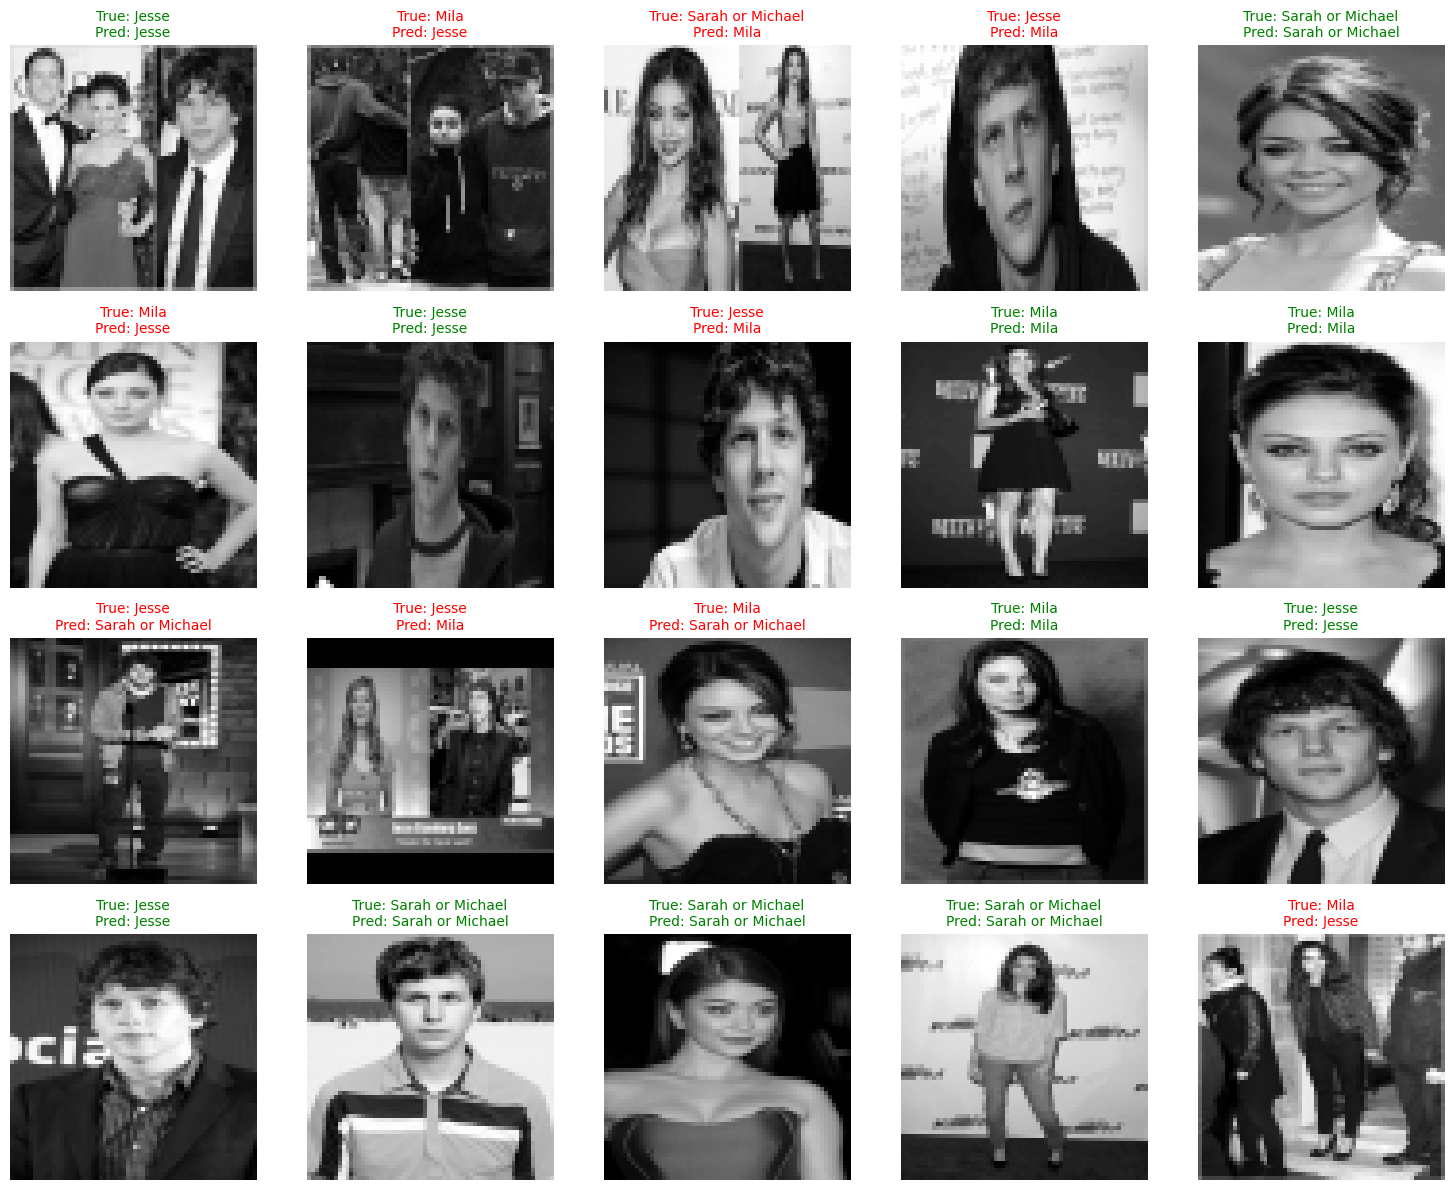

In [58]:
# 1. Grab the actual images for the validation set (using the same split)
_, X_val_img, _, _ = get_validation_split(
    df=train_hog, 
    feature_col='img_resized', # Point this to your image column!
    label_col='class'
)

# 2. Plot them using the function from visualize_validation.py
plot_validation_images(
    X_val_images=X_val_img, 
    y_val_true=y_val_hog, 
    y_val_pred=y_val_pred, 
    class_names=target_names
)

# 5. Publishing best results

In [ ]:
submission = test.copy().drop('img', axis = 1)
submission['class'] = test_y_star

submission

In [ ]:
submission.to_csv('submission.csv')

# 6. Discussion
...

In summary we contributed the following: 
* 
